In [195]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
import scipy
import emcee
import time
import corner

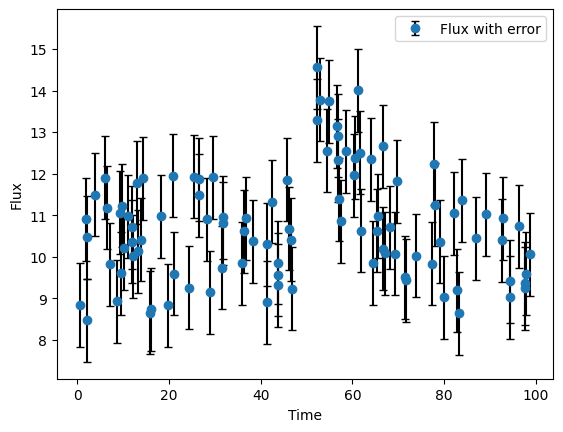

In [196]:
data=np.load("Transient.npy")
times=data[:,0]
flux=data[:,1]
err=data[:,2]
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

Try with Log to avoid RuntimeWarning

In [ ]:
# def burst (x):  #our burst model, x are parameters  x[0] = t0, x[2] = A, x[1] = b, x[3] = alpha
#     if times<x[0]:           #data are fixed 
#         return x[1]
#     else:   
#         return x[1] + x[2]*np.exp(-(times-x[0])*x[3])


def distances (x):
    if np.any(np.abs(x) > 1e6):             
        return np.inf              
    for i in range(len(times)):
        if times[i]<x[0]:
            return np.abs(flux[i]-x[1])/err[i]
        else:
            return np.abs(flux[i]-(x[1] + x[2]*np.exp(-(times[i]-x[0])*x[3])))/err[i]

def LogLikelihood(x):
   return 

 
def prior(x):
    if x[3]==0:
        return np.inf
    prior_t0=1/100
    prior_A=1/50
    prior_b=1/50
    prior_alpha=1/(10*x[3])
    return prior_t0*prior_A*prior_b*prior_alpha

def LogPosterior (x):
    if prior(x)<=0:
        return -np.inf
    else:
        return LogLikelihood(x) + np.log(prior(x))


16.603591918945312
(8250, 4)


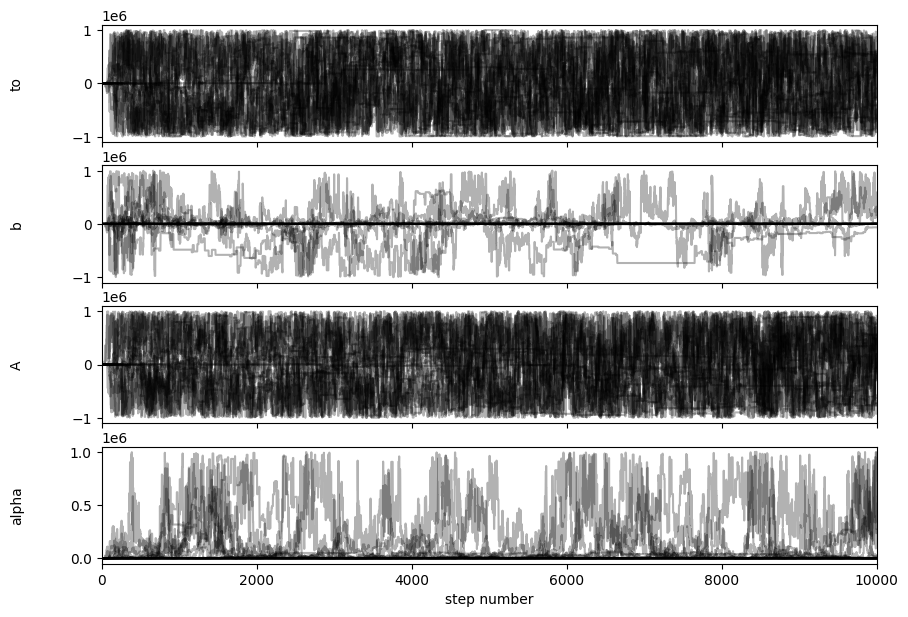

In [ ]:
ndim = 4  # number of parameters in the model
nwalkers = 25  # number of MCMC walkers
burn = 10000  # "burn-in" period to let chains stabilize
nsteps = 10000  # number of MCMC steps to take **for each walker**

# initialize theta 
np.random.seed(0)
starting_guesses = np.random.random((nwalkers, ndim)) #starting point for each walker for each parameter

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
elapsed=time.time()
sampler.run_mcmc(starting_guesses, nsteps)
print(time.time()-elapsed)

fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["to","b", "A", "alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

flat_samples = sampler.get_chain(discard=100, thin=30, flat=True)


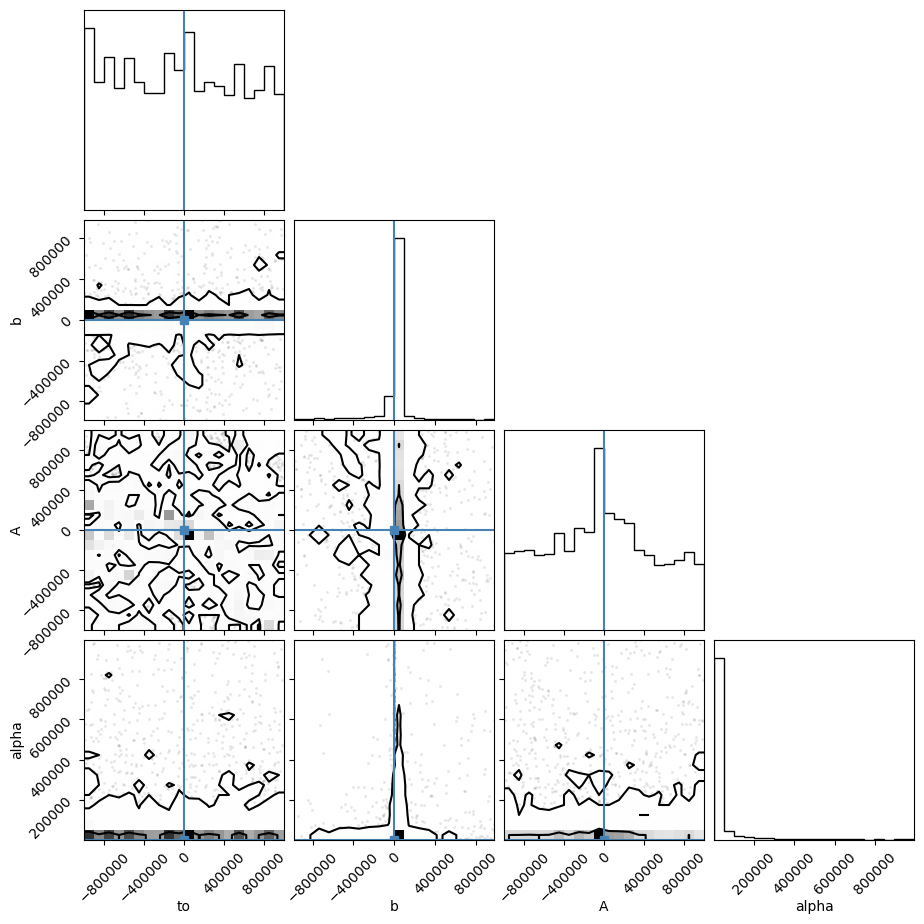

In [208]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95],truths=[50,11,15,10])